m* = 2kd/ka = 0.4  →  M* = 199.6


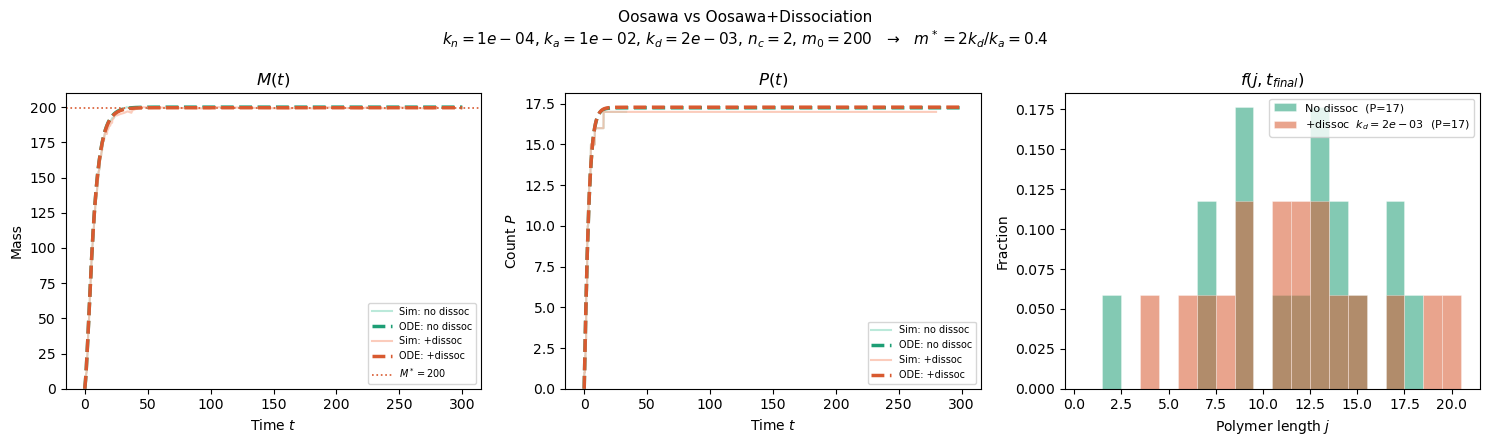

  kd=0e+00  m*=0.0
  kd=5e-04  m*=0.1
  kd=1e-03  m*=0.2
  kd=3e-03  m*=0.6


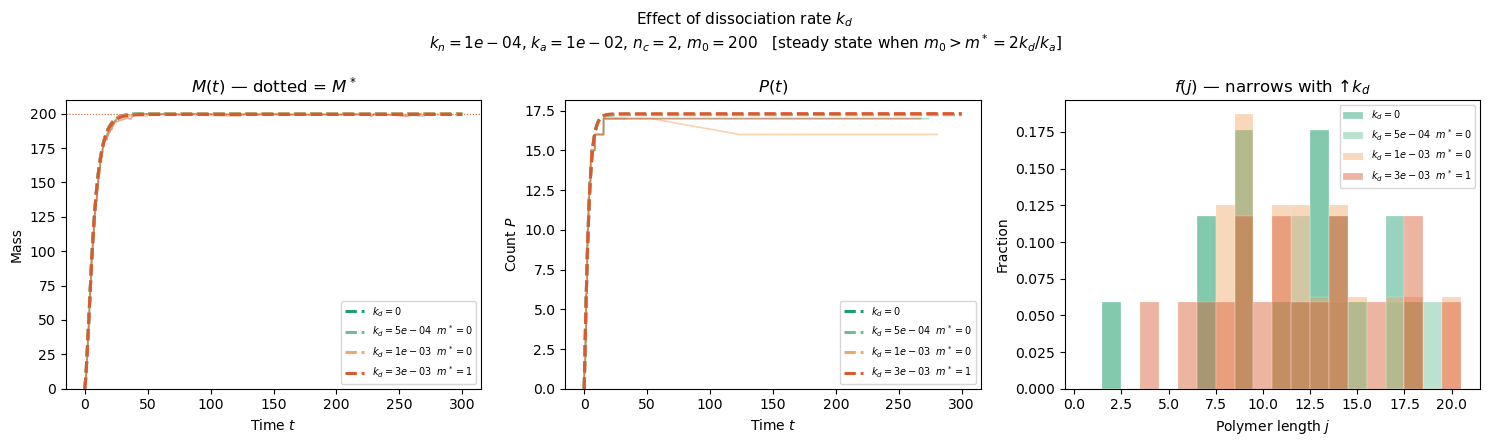

  ka=5e-03  m*=0.8
  ka=1e-02  m*=0.4
  ka=2e-02  m*=0.2


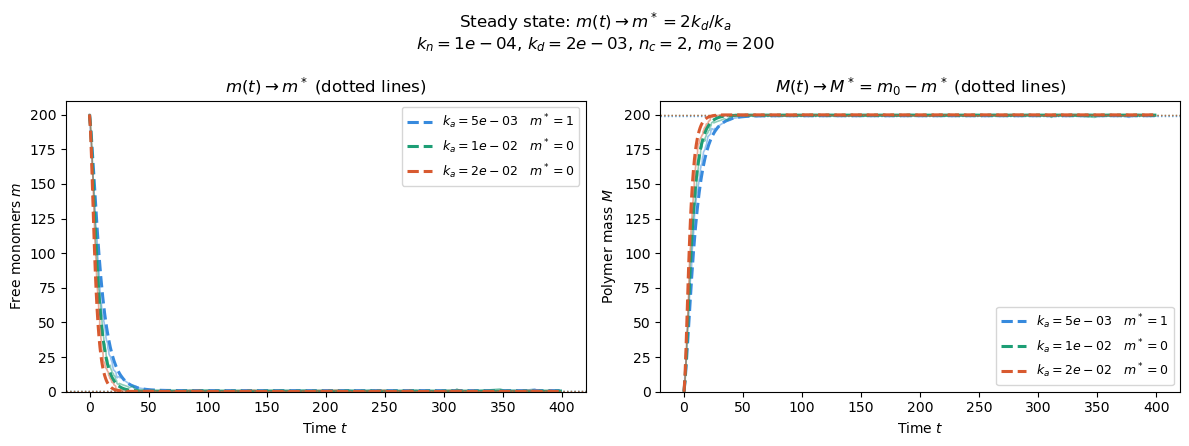

In [1]:
"""
Oosawa Model + Dissociation — Gillespie Stochastic Simulation
==============================================================
Week 1, Question 3: Investigate how dissociation affects aggregation.

Reactions:
  Nucleation:   nc monomers → polymer(nc),            rate = kn * m^nc
  Association:  polymer(j) + monomer → polymer(j+1),  rate = ka * m  [per polymer]
  Dissociation: polymer(j) → polymer(j-1) + monomer,  rate = kd      [per polymer]
                (polymer dissolves if length drops below nc)

Key result:
  Steady state when  m(t) → m* = 2*kd/ka
  Condition for polymers to exist:  m0 > m* = 2*kd/ka
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ──────────────────────────────────────────────────────────────
# GILLESPIE WITH DISSOCIATION
# ──────────────────────────────────────────────────────────────

def gillespie_dissociation(kn, ka, kd, nc, m0,
                            t_max=300.0,
                            max_events=200_000,
                            seed=42):
    """
    Stops at t_max (not m==0) because with dissociation
    the system reaches steady state and m never hits zero.
    """
    rng = np.random.default_rng(seed=seed)
    t = 0.0; m = m0; P = 0; M = 0.0
    polymers = []
    t_series = [0.0]; m_series = [float(m)]
    P_series = [0];   M_series = [0.0]

    for _ in range(max_events):
        r_nucl   = kn * (m ** nc) if m >= nc        else 0.0
        r_assoc  = ka * m * P     if m > 0 and P > 0 else 0.0
        r_dissoc = kd * P         if P > 0           else 0.0
        r_total  = r_nucl + r_assoc + r_dissoc

        if r_total <= 0:
            break

        tau = -np.log(rng.random()) / r_total
        t  += tau

        if t >= t_max:
            break

        u = rng.random() * r_total

        if u < r_nucl:
            polymers.append(nc); m -= nc; M += nc; P += 1

        elif u < r_nucl + r_assoc:
            idx = rng.integers(0, P)
            polymers[idx] += 1; m -= 1; M += 1

        else:
            idx = rng.integers(0, P)
            polymers[idx] -= 1; m += 1; M -= 1
            if polymers[idx] < nc:
                extra = polymers[idx]
                m += extra; M -= extra
                polymers.pop(idx); P -= 1

        t_series.append(t); m_series.append(float(m))
        P_series.append(P); M_series.append(float(M))

    return (np.array(t_series), np.array(m_series),
            np.array(P_series),  np.array(M_series),
            list(polymers))


# ──────────────────────────────────────────────────────────────
# ODE THEORY
# ──────────────────────────────────────────────────────────────

def solve_ode(kn, ka, kd, nc, m0, t_end, n=500):
    def odes(t, y):
        P, M = y; m = max(m0 - M, 0.0)
        return [kn * (m**nc),
                (ka*m - 2*kd)*P + nc*kn*(m**nc)]
    sol = solve_ivp(odes, [0, t_end], [0., 0.],
                    t_eval=np.linspace(0, t_end, n),
                    method='RK45', rtol=1e-8, atol=1e-10)
    return sol.t, m0 - sol.y[1], sol.y[0], sol.y[1]


# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Oosawa vs Oosawa+Dissociation
# ══════════════════════════════════════════════════════════════

KN, KA, KD, NC, M0 = 1e-4, 1e-2, 2e-3, 2, 200
T_MAX = 300.0
m_star = 2 * KD / KA
print(f"m* = 2kd/ka = {m_star:.1f}  →  M* = {M0 - m_star:.1f}")

t0, m0s, P0, M0s, poly0 = gillespie_dissociation(KN, KA, 0.0, NC, M0, t_max=T_MAX)
td, mds, Pd, Md, polyd  = gillespie_dissociation(KN, KA,  KD, NC, M0, t_max=T_MAX)
t_th0, m_th0, P_th0, M_th0 = solve_ode(KN, KA, 0.0, NC, M0, T_MAX)
t_thd, m_thd, P_thd, M_thd = solve_ode(KN, KA,  KD, NC, M0, T_MAX)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    f"Oosawa vs Oosawa+Dissociation\n"
    f"$k_n={KN:.0e}$, $k_a={KA:.0e}$, $k_d={KD:.0e}$, $n_c={NC}$, $m_0={M0}$"
    f"   →   $m^* = 2k_d/k_a = {m_star:.1f}$",
    fontsize=11)

axes[0].plot(t0,   M0s,   color="#9FE1CB", lw=1.5, alpha=0.7, label="Sim: no dissoc")
axes[0].plot(t_th0,M_th0, color="#1D9E75", lw=2.5, ls="--",   label="ODE: no dissoc")
axes[0].plot(td,   Md,    color="#FAB7A0", lw=1.5, alpha=0.7, label="Sim: +dissoc")
axes[0].plot(t_thd,M_thd, color="#D85A30", lw=2.5, ls="--",   label="ODE: +dissoc")
axes[0].axhline(M0 - m_star, color="#D85A30", lw=1.2, ls=":", label=f"$M^*={M0-m_star:.0f}$")
axes[0].set(xlabel="Time $t$", ylabel="Mass", title="$M(t)$")
axes[0].legend(fontsize=7); axes[0].set_ylim(bottom=0)

axes[1].plot(t0,   P0,    color="#9FE1CB", lw=1.5, alpha=0.7, label="Sim: no dissoc")
axes[1].plot(t_th0,P_th0, color="#1D9E75", lw=2.5, ls="--",   label="ODE: no dissoc")
axes[1].plot(td,   Pd,    color="#FAB7A0", lw=1.5, alpha=0.7, label="Sim: +dissoc")
axes[1].plot(t_thd,P_thd, color="#D85A30", lw=2.5, ls="--",   label="ODE: +dissoc")
axes[1].set(xlabel="Time $t$", ylabel="Count $P$", title="$P(t)$")
axes[1].legend(fontsize=7); axes[1].set_ylim(bottom=0)

for polys, color, label in [
    (poly0, "#1D9E75", f"No dissoc  (P={len(poly0)})"),
    (polyd, "#D85A30", f"+dissoc  $k_d={KD:.0e}$  (P={len(polyd)})")
]:
    if polys:
        arr = np.array(polys)
        axes[2].hist(arr, bins=np.arange(0.5, max(arr)+1.5, 1),
                     color=color, alpha=0.55, edgecolor="white",
                     lw=0.4, density=True, label=label)
axes[2].set(xlabel="Polymer length $j$", ylabel="Fraction",
            title="$f(j,t_{final})$")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Vary kd
# ══════════════════════════════════════════════════════════════

KN, KA, NC, M0 = 1e-4, 1e-2, 2, 200
T_MAX = 300.0
kd_values = [0.0, 5e-4, 1e-3, 3e-3]
colors    = ["#1D9E75", "#6ABF97", "#F0A868", "#D85A30"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    f"Effect of dissociation rate $k_d$\n"
    f"$k_n={KN:.0e}$, $k_a={KA:.0e}$, $n_c={NC}$, $m_0={M0}$"
    f"   [steady state when $m_0 > m^* = 2k_d/k_a$]",
    fontsize=11)

for kd, color in zip(kd_values, colors):
    m_star = 2 * kd / KA
    label  = f"$k_d={kd:.0e}$  $m^*={m_star:.0f}$" if kd > 0 else "$k_d=0$"
    print(f"  kd={kd:.0e}  m*={m_star:.1f}")

    t, m, P, M, polys = gillespie_dissociation(KN, KA, kd, NC, M0, t_max=T_MAX)
    t_th, m_th, P_th, M_th = solve_ode(KN, KA, kd, NC, M0, T_MAX)

    axes[0].plot(t,    M,    color=color, lw=1.2, alpha=0.5)
    axes[0].plot(t_th, M_th, color=color, lw=2.2, ls="--", label=label)
    if kd > 0:
        axes[0].axhline(M0 - m_star, color=color, lw=0.8, ls=":", alpha=0.7)

    axes[1].plot(t,    P,    color=color, lw=1.2, alpha=0.5)
    axes[1].plot(t_th, P_th, color=color, lw=2.2, ls="--", label=label)

    if polys:
        arr = np.array(polys)
        axes[2].hist(arr, bins=np.arange(0.5, max(arr)+1.5, 1),
                     color=color, alpha=0.45, edgecolor="white",
                     lw=0.3, density=True, label=label)

axes[0].set(xlabel="Time $t$", ylabel="Mass", title="$M(t)$ — dotted = $M^*$")
axes[0].legend(fontsize=7); axes[0].set_ylim(bottom=0)
axes[1].set(xlabel="Time $t$", ylabel="Count $P$", title="$P(t)$")
axes[1].legend(fontsize=7); axes[1].set_ylim(bottom=0)
axes[2].set(xlabel="Polymer length $j$", ylabel="Fraction",
            title="$f(j)$ — narrows with ↑$k_d$")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# FIGURE 3 — Steady state verification
# ══════════════════════════════════════════════════════════════

KN, KD, NC, M0 = 1e-4, 2e-3, 2, 200
T_MAX = 400.0
KA_values = [5e-3, 1e-2, 2e-2]
colors    = ["#378ADD", "#1D9E75", "#D85A30"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(
    f"Steady state: $m(t) \\rightarrow m^* = 2k_d/k_a$\n"
    f"$k_n={KN:.0e}$, $k_d={KD:.0e}$, $n_c={NC}$, $m_0={M0}$",
    fontsize=12)

for KA, color in zip(KA_values, colors):
    m_star = 2 * KD / KA
    label  = f"$k_a={KA:.0e}$   $m^*={m_star:.0f}$"
    print(f"  ka={KA:.0e}  m*={m_star:.1f}")

    t, m, P, M, _ = gillespie_dissociation(KN, KA, KD, NC, M0, t_max=T_MAX)
    t_th, m_th, P_th, M_th = solve_ode(KN, KA, KD, NC, M0, T_MAX)

    axes[0].plot(t,    m,    color=color, lw=1.2, alpha=0.5)
    axes[0].plot(t_th, m_th, color=color, lw=2.2, ls="--", label=label)
    axes[0].axhline(m_star, color=color, lw=1.0, ls=":", alpha=0.8)

    axes[1].plot(t,    M,    color=color, lw=1.2, alpha=0.5)
    axes[1].plot(t_th, M_th, color=color, lw=2.2, ls="--", label=label)
    axes[1].axhline(M0 - m_star, color=color, lw=1.0, ls=":", alpha=0.8)

axes[0].set(xlabel="Time $t$", ylabel="Free monomers $m$",
            title="$m(t) \\rightarrow m^*$ (dotted lines)")
axes[0].legend(fontsize=9); axes[0].set_ylim(bottom=0)
axes[1].set(xlabel="Time $t$", ylabel="Polymer mass $M$",
            title="$M(t) \\rightarrow M^* = m_0 - m^*$ (dotted lines)")
axes[1].legend(fontsize=9); axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()